# Notebook 01 — CIFAR-10 Federated Learning & Membership Inference Attack
**DS Lab 2 | Membership Inference Attacks in Federated Learning**

This notebook implements the complete experimental pipeline for the CIFAR-10 dataset.
It is fully self-contained — just run all cells from top to bottom.

**What this notebook does:**
- Loads and preprocesses CIFAR-10 (50,000 training / 10,000 test, 10 classes)
- Partitions data across federated clients using IID partitioning
- Simulates federated learning using the FedAvg algorithm
- Evaluates a black-box membership inference attack against the trained global model
- Addresses all three research questions:
  - **RQ1:** Can a black-box MIA succeed against a federated learning model?
  - **RQ2:** How does the number of clients affect attack success?
  - **RQ3:** How does model complexity affect privacy leakage?

**Configuration:** 5 clients | 10 communication rounds | 3 local epochs per round


## 1. Imports & Configuration


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import json, os, gc

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# ── Experiment configuration ──────────────────────────────────────────────────
NUM_CLIENTS   = 5        # number of federated clients
NUM_ROUNDS    = 10       # number of federated communication rounds
LOCAL_EPOCHS  = 3        # local training epochs per round per client
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
NUM_CLASSES   = 10       # CIFAR-10 has 10 classes
RANDOM_SEED   = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
gc.collect()
tf.keras.backend.clear_session()

OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"Config     : {NUM_CLIENTS} clients | {NUM_ROUNDS} rounds | {LOCAL_EPOCHS} local epochs")


TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Config     : 5 clients | 10 rounds | 3 local epochs


## 2. Load & Preprocess CIFAR-10


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Training set : {x_train.shape}  labels: {y_train.shape}")
print(f"Test set     : {x_test.shape}   labels: {y_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training set : (50000, 32, 32, 3)  labels: (50000,)
Test set     : (10000, 32, 32, 3)   labels: (10000,)


## 3. Helper Functions

This section defines all reusable functions for the pipeline:
- `partition_data_iid` — splits training data equally across clients
- `build_model` — defines the CNN architecture (small or large)
- `fedavg_aggregate` — computes weighted average of client weights
- `local_train` — trains a client model for one round
- `train_attack_model` — trains and evaluates the logistic regression attacker
- `run_fl_and_attack` — runs the full pipeline end to end (used for RQ2 & RQ3)


In [ ]:
def partition_data_iid(x, y, num_clients, seed=42):
    """Shuffle and split data equally across clients (IID partitioning)."""
    rng     = np.random.default_rng(seed)
    indices = rng.permutation(len(x))
    splits  = np.array_split(indices, num_clients)
    client_data    = [(x[idx], y[idx]) for idx in splits]
    client_indices = [idx.tolist() for idx in splits]
    return client_data, client_indices


def build_model(num_classes=10, learning_rate=0.001, complexity='small'):
    """
    CNN for CIFAR-10 classification.
    complexity: 'small' (2 conv blocks) or 'large' (4 conv layers)
    """
    if complexity == 'small':
        model = keras.Sequential([
            layers.Input(shape=(32, 32, 3)),
            layers.Conv2D(32, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Conv2D(64, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation='softmax'),
        ])
    else:
        model = keras.Sequential([
            layers.Input(shape=(32, 32, 3)),
            layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
            layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Conv2D(128, (3,3), activation='relu', padding='same'),
            layers.Conv2D(128, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.4),
            layers.Dense(num_classes, activation='softmax'),
        ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def fedavg_aggregate(client_weights, client_sizes):
    """Weighted average of client model weights proportional to dataset size."""
    total = sum(client_sizes)
    return [
        sum((s / total) * w for w, s in zip(layer_ws, client_sizes))
        for layer_ws in zip(*client_weights)
    ]


def local_train(global_weights, x_c, y_c, local_epochs,
                batch_size, lr, complexity='small'):
    """Train a local client model starting from the current global weights."""
    m = build_model(learning_rate=lr, complexity=complexity)
    m.set_weights(global_weights)
    m.fit(x_c, y_c, epochs=local_epochs, batch_size=batch_size, verbose=0)
    return m.get_weights()


def train_attack_model(X, y, test_size=0.3, seed=42):
    """Train a logistic regression membership inference attacker and return metrics."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    attacker = LogisticRegression(max_iter=1000, random_state=seed)
    attacker.fit(X_tr, y_tr)

    y_pred      = attacker.predict(X_te)
    y_pred_prob = attacker.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_pred_prob)

    return attacker, {
        'accuracy'  : accuracy_score(y_te, y_pred),
        'precision' : precision_score(y_te, y_pred),
        'recall'    : recall_score(y_te, y_pred),
        'auc'       : roc_auc_score(y_te, y_pred_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
    }, (X_te, y_te)


def run_fl_and_attack(num_clients, num_rounds=6, local_epochs=2,
                      batch_size=64, lr=0.001, complexity='small',
                      seed=42, n_attack_samples=1000):
    """Full pipeline: FL training → attack data collection → attacker evaluation."""
    gc.collect()
    tf.keras.backend.clear_session()

    client_data, client_indices = partition_data_iid(x_train, y_train, num_clients, seed)
    member_idx   = [i for sublist in client_indices for i in sublist]
    client_sizes = [len(xc) for xc, _ in client_data]

    gm = build_model(learning_rate=lr, complexity=complexity)
    gw = gm.get_weights()
    for _ in range(num_rounds):
        cw_list = [local_train(gw, xc, yc, local_epochs, batch_size, lr, complexity)
                   for xc, yc in client_data]
        gw = fedavg_aggregate(cw_list, client_sizes)
        gm.set_weights(gw)

    rng    = np.random.default_rng(seed)
    m_idx  = rng.choice(member_idx,  size=n_attack_samples, replace=False)
    nm_idx = rng.choice(len(x_test), size=n_attack_samples, replace=False)
    m_probs  = gm.predict(x_train[m_idx],  batch_size=256, verbose=0)
    nm_probs = gm.predict(x_test[nm_idx],  batch_size=256, verbose=0)
    X_atk = np.vstack([m_probs, nm_probs])
    y_atk = np.array([1]*n_attack_samples + [0]*n_attack_samples)

    _, m, _ = train_attack_model(X_atk, y_atk, seed=seed)
    _, acc  = gm.evaluate(x_test, y_test, verbose=0)
    m['global_acc'] = acc

    del gm, cw_list, m_probs, nm_probs, X_atk
    gc.collect()
    return m


print("All helper functions defined.")


All helper functions defined.


## 4. Federated Learning Training (RQ1 Baseline)

The global model is trained using FedAvg across 5 clients for 10 communication rounds.
Each client trains locally for 3 epochs on its private data partition before sending
weight updates to the central server for aggregation.


  Client 1: 10000 samples
  Client 2: 10000 samples
  Client 3: 10000 samples
  Client 4: 10000 samples
  Client 5: 10000 samples

Starting federated training...

Round 01/10 | Test accuracy: 0.4704 | Loss: 1.6876
Round 02/10 | Test accuracy: 0.6146 | Loss: 1.1022
Round 03/10 | Test accuracy: 0.6579 | Loss: 0.9777
Round 04/10 | Test accuracy: 0.6797 | Loss: 0.9151
Round 05/10 | Test accuracy: 0.6934 | Loss: 0.8865
Round 06/10 | Test accuracy: 0.7042 | Loss: 0.8616
Round 07/10 | Test accuracy: 0.7078 | Loss: 0.8600
Round 08/10 | Test accuracy: 0.7134 | Loss: 0.8577
Round 09/10 | Test accuracy: 0.7140 | Loss: 0.8721
Round 10/10 | Test accuracy: 0.7203 | Loss: 0.8800

Federated training complete. Final accuracy: 0.7203


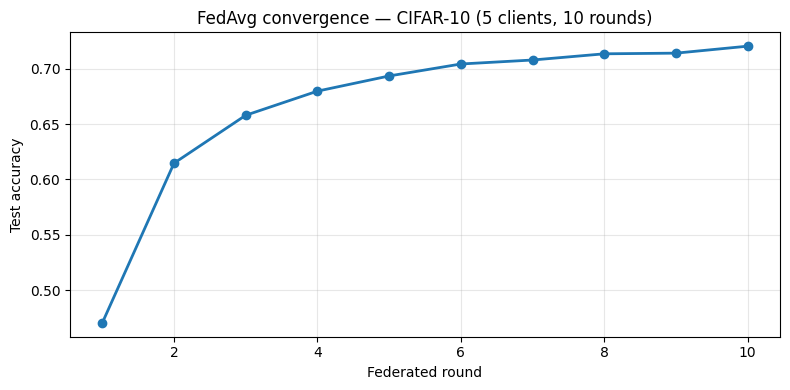

In [ ]:
client_data, client_indices = partition_data_iid(x_train, y_train, NUM_CLIENTS, RANDOM_SEED)
member_indices = [i for sublist in client_indices for i in sublist]
client_sizes   = [len(xc) for xc, _ in client_data]

for i, (xc, yc) in enumerate(client_data):
    print(f"  Client {i+1}: {xc.shape[0]} samples")

global_model   = build_model(num_classes=NUM_CLASSES, learning_rate=LEARNING_RATE)
global_weights = global_model.get_weights()
round_accuracies = []

print("\nStarting federated training...\n")
for round_num in range(1, NUM_ROUNDS + 1):
    cw_list = [
        local_train(global_weights, xc, yc, LOCAL_EPOCHS, BATCH_SIZE, LEARNING_RATE)
        for xc, yc in client_data
    ]
    global_weights = fedavg_aggregate(cw_list, client_sizes)
    global_model.set_weights(global_weights)
    loss, acc = global_model.evaluate(x_test, y_test, verbose=0)
    round_accuracies.append(acc)
    print(f"Round {round_num:02d}/{NUM_ROUNDS} | Test accuracy: {acc:.4f} | Loss: {loss:.4f}")

print(f"\nFederated training complete. Final accuracy: {round_accuracies[-1]:.4f}")

# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_ROUNDS+1), round_accuracies, marker='o', linewidth=2)
plt.xlabel("Federated round")
plt.ylabel("Test accuracy")
plt.title(f"FedAvg convergence — CIFAR-10 ({NUM_CLIENTS} clients, {NUM_ROUNDS} rounds)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar10_convergence.png'), dpi=150)
plt.show()


## 5. Build the Attacker Dataset

The attacker has **black-box access** — they can only query the global model
and observe the softmax output probabilities. They cannot see model weights or gradients.

- **Members** (label = 1): samples used during FL training
- **Non-members** (label = 0): unseen test samples

The attacker's feature vector for each sample is the model's full 10-dimensional
softmax output — one confidence score per class.


In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
n   = 5000

m_idx  = rng.choice(member_indices, size=n, replace=False)
nm_idx = rng.choice(len(x_test),    size=n, replace=False)

print("Querying model on member samples...")
m_probs  = global_model.predict(x_train[m_idx],  batch_size=256, verbose=1)
print("Querying model on non-member samples...")
nm_probs = global_model.predict(x_test[nm_idx],  batch_size=256, verbose=1)

X_attack = np.vstack([m_probs, nm_probs])
y_attack = np.array([1]*n + [0]*n)

print(f"\nAttacker dataset: {X_attack.shape} — {n} members + {n} non-members")


Querying model on member samples...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Querying model on non-member samples...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Attacker dataset: (10000, 10) — 5000 members + 5000 non-members


## 6. RQ1 — Train the Attacker & Evaluate

A logistic regression binary classifier is trained on the attacker dataset.
It learns to distinguish members from non-members based on confidence score patterns.
Performance is measured using Accuracy, Precision, Recall and AUC.
A random-chance baseline of 0.50 applies to all metrics.



── RQ1 Attack Results (CIFAR-10, 5 clients) ─────────────
  Accuracy  : 0.4940
  Precision : 0.4929
  Recall    : 0.4160
  AUC       : 0.4967
─────────────────────────────────────────────────────────
(Random-chance baseline = 0.50 for all metrics)


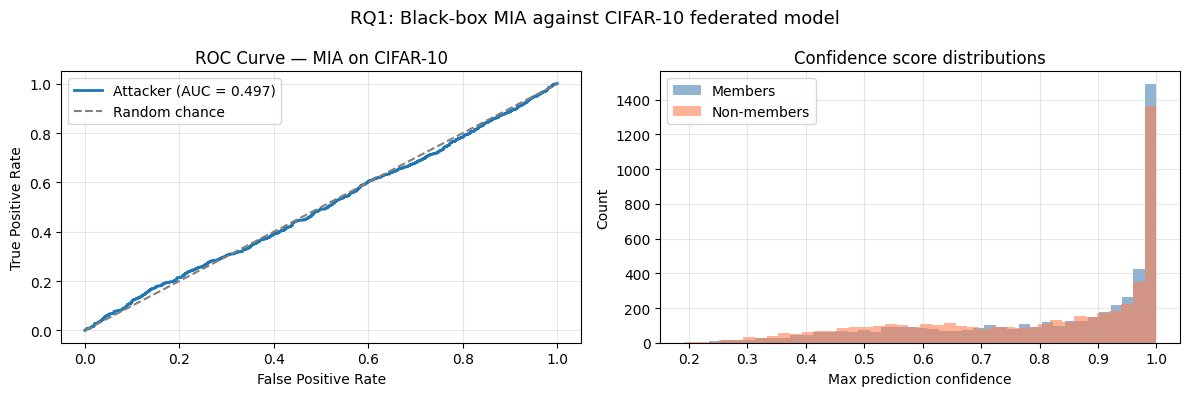

In [ ]:
attacker, metrics, (X_te, y_te) = train_attack_model(X_attack, y_attack)

print("\n── RQ1 Attack Results (CIFAR-10, 5 clients) ─────────────")
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  AUC       : {metrics['auc']:.4f}")
print("─────────────────────────────────────────────────────────")
print("(Random-chance baseline = 0.50 for all metrics)")

# Plot ROC curve and confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(metrics['fpr'], metrics['tpr'],
        linewidth=2, label=f"Attacker (AUC = {metrics['auc']:.3f})")
ax.plot([0,1],[0,1], '--', color='gray', label='Random chance')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — MIA on CIFAR-10")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(X_attack[:n].max(axis=1), bins=40, alpha=0.6, label='Members',     color='steelblue')
ax.hist(X_attack[n:].max(axis=1), bins=40, alpha=0.6, label='Non-members', color='coral')
ax.set_xlabel("Max prediction confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence score distributions")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("RQ1: Black-box MIA against CIFAR-10 federated model", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar10_rq1_results.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6b. Baseline Attacks — Comparison

Before evaluating the logistic regression attacker, two simpler baseline attacks
are evaluated to provide a meaningful comparison:

- **Random baseline** — predicts membership randomly (theoretical floor, AUC = 0.50)
- **Threshold attack** — predicts member if max softmax confidence exceeds a fixed threshold
- **Loss-based attack** — uses the model's cross-entropy loss as the membership signal;
  lower loss → more likely member

The logistic regression attacker (our proposed method) is then compared against these baselines.
A strong attacker should outperform all three baselines.


══════════════════════════════════════════════════════════
Baseline Comparison — CIFAR-10 (RQ1)
══════════════════════════════════════════════════════════
Method                           Accuracy        AUC
----------------------------------------------------------
Random baseline                    0.4925     0.4969
Threshold attack                   0.5128     0.5355
Loss-based attack                  0.5506     0.5768
Logistic regression (ours)         0.4940     0.4967
══════════════════════════════════════════════════════════
Random-chance baseline = 0.50 for all metrics


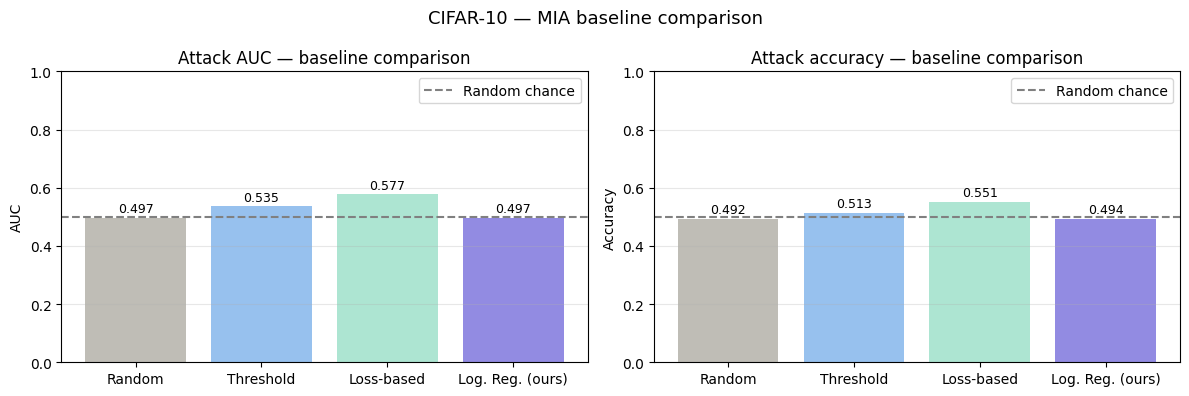

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

# ── Shared test labels (from attacker dataset) ────────────────────────────────
# X_attack: rows 0..n-1 = members, rows n..2n-1 = non-members
# y_attack: 1 = member, 0 = non-member

# ── Baseline 1: Random ───────────────────────────────────────────────────────
rng_b = np.random.default_rng(RANDOM_SEED)
random_scores = rng_b.uniform(0, 1, size=len(y_attack))
random_auc    = roc_auc_score(y_attack, random_scores)
random_acc    = accuracy_score(y_attack, (random_scores > 0.5).astype(int))

# ── Baseline 2: Threshold attack (max confidence) ────────────────────────────
# Higher max confidence → more likely to be a member
max_conf       = X_attack.max(axis=1)
threshold      = 0.5
thresh_preds   = (max_conf > threshold).astype(int)
thresh_auc     = roc_auc_score(y_attack, max_conf)
thresh_acc     = accuracy_score(y_attack, thresh_preds)

# ── Baseline 3: Loss-based attack ─────────────────────────────────────────────
# Lower cross-entropy loss → model is more confident → likely a member
# We use negative loss as the membership score so higher score = more likely member
epsilon   = 1e-10
true_labels_onehot = np.zeros_like(X_attack)

# Get true labels for member and non-member samples
rng2 = np.random.default_rng(RANDOM_SEED)
m_idx_b  = rng2.choice(member_indices, size=n, replace=False)
nm_idx_b = rng2.choice(len(x_test),    size=n, replace=False)
all_labels = np.concatenate([y_train[m_idx_b], y_test[nm_idx_b]])

for i, label in enumerate(all_labels):
    true_labels_onehot[i, int(label)] = 1

cross_entropy  = -np.sum(true_labels_onehot * np.log(X_attack + epsilon), axis=1)
loss_scores    = -cross_entropy  # negate: lower loss = higher membership score
loss_preds     = (loss_scores > np.median(loss_scores)).astype(int)
loss_auc       = roc_auc_score(y_attack, loss_scores)
loss_acc       = accuracy_score(y_attack, loss_preds)

# ── Our method: Logistic Regression (already computed above) ─────────────────
lr_auc = metrics['auc']
lr_acc = metrics['accuracy']

# ── Print comparison table ────────────────────────────────────────────────────
print("═" * 58)
print("Baseline Comparison — CIFAR-10 (RQ1)")
print("═" * 58)
print(f"{'Method':<30} {'Accuracy':>10} {'AUC':>10}")
print("-" * 58)
print(f"{'Random baseline':<30} {random_acc:>10.4f} {random_auc:>10.4f}")
print(f"{'Threshold attack':<30} {thresh_acc:>10.4f} {thresh_auc:>10.4f}")
print(f"{'Loss-based attack':<30} {loss_acc:>10.4f} {loss_auc:>10.4f}")
print(f"{'Logistic regression (ours)':<30} {lr_acc:>10.4f} {lr_auc:>10.4f}")
print("═" * 58)
print("Random-chance baseline = 0.50 for all metrics")

# ── Plot: baseline comparison bar chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = ['Random', 'Threshold', 'Loss-based', 'Log. Reg. (ours)']
aucs    = [random_auc, thresh_auc, loss_auc, lr_auc]
accs    = [random_acc, thresh_acc, loss_acc, lr_acc]
colors  = ['#B4B2A9', '#85B7EB', '#9FE1CB', '#7F77DD']

ax = axes[0]
bars = ax.bar(methods, aucs, color=colors, alpha=0.85)
ax.axhline(0.5, linestyle='--', color='gray', label='Random chance')
ax.set_ylabel('AUC')
ax.set_title('Attack AUC — baseline comparison')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(methods, accs, color=colors, alpha=0.85)
ax.axhline(0.5, linestyle='--', color='gray', label='Random chance')
ax.set_ylabel('Accuracy')
ax.set_title('Attack accuracy — baseline comparison')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('CIFAR-10 — MIA baseline comparison', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar10_baseline_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Store for summary
baseline_results = {
    'random'    : {'accuracy': float(random_acc), 'auc': float(random_auc)},
    'threshold' : {'accuracy': float(thresh_acc), 'auc': float(thresh_auc)},
    'loss'      : {'accuracy': float(loss_acc),   'auc': float(loss_auc)},
    'logistic'  : {'accuracy': float(lr_acc),     'auc': float(lr_auc)},
}


## 7. RQ2 — Effect of Number of Clients on Attack Success

The full FL-and-attack pipeline is re-run with different numbers of clients
while keeping all other parameters fixed. This measures whether federation size
has any meaningful effect on the attacker's ability to infer training membership.


In [ ]:
client_counts = [2, 5, 10]
rq2_results   = {}

for nc in client_counts:
    print(f"\n── {nc} clients ──")
    rq2_results[nc] = run_fl_and_attack(
        num_clients=nc, num_rounds=6, local_epochs=2,
        complexity='small', n_attack_samples=1000
    )
    print(f"  Global acc : {rq2_results[nc]['global_acc']:.4f}")
    print(f"  Attack AUC : {rq2_results[nc]['auc']:.4f}")

print("\nRQ2 complete.")



── 2 clients ──
  Global acc : 0.7069
  Attack AUC : 0.4932

── 5 clients ──
  Global acc : 0.6784
  Attack AUC : 0.5123

── 10 clients ──
  Global acc : 0.6415
  Attack AUC : 0.5027

RQ2 complete.


## 8. RQ3 — Effect of Model Complexity on Privacy Leakage

The pipeline is re-run with two CNN architectures of different complexity —
a small model (2 convolutional blocks) and a large model (4 convolutional layers) —
to measure whether model size affects privacy leakage in the federated setting.


In [ ]:
complexities = ['small', 'large']
rq3_results  = {}

for c in complexities:
    print(f"\n── '{c}' model ──")
    rq3_results[c] = run_fl_and_attack(
        num_clients=5, num_rounds=6, local_epochs=2,
        complexity=c, n_attack_samples=1000
    )
    print(f"  Global acc : {rq3_results[c]['global_acc']:.4f}")
    print(f"  Attack AUC : {rq3_results[c]['auc']:.4f}")

print("\nRQ3 complete.")



── 'small' model ──
  Global acc : 0.6811
  Attack AUC : 0.4946

── 'large' model ──
  Global acc : 0.7442
  Attack AUC : 0.5031

RQ3 complete.


## 9. Plot RQ2 & RQ3 Results


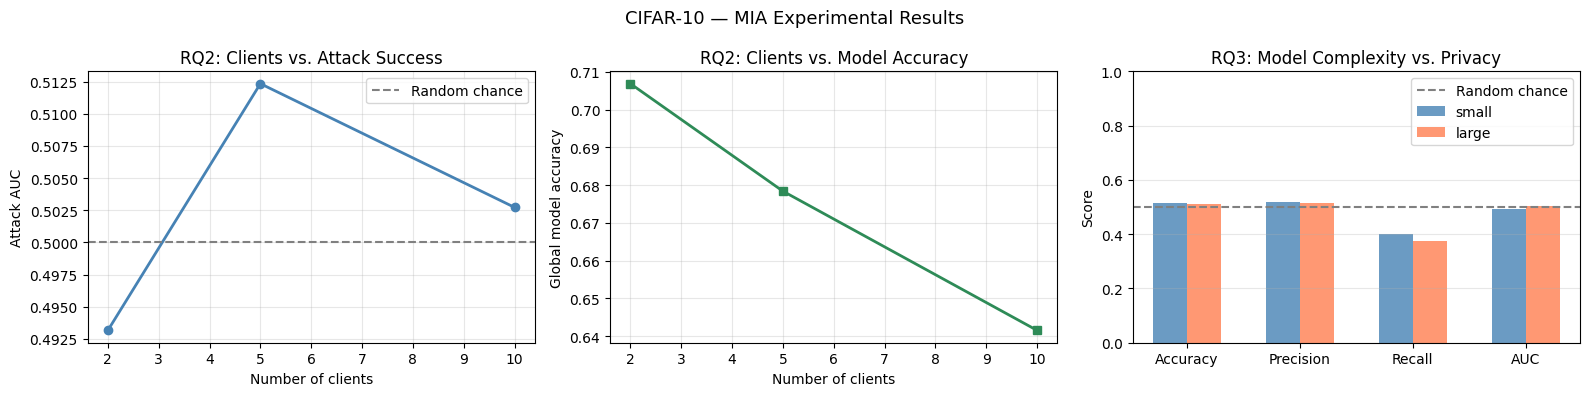

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
nc_vals  = list(rq2_results.keys())
auc_vals = [rq2_results[nc]['auc'] for nc in nc_vals]
ax.plot(nc_vals, auc_vals, marker='o', linewidth=2, color='steelblue')
ax.axhline(0.5, linestyle='--', color='gray', label='Random chance')
ax.set_xlabel("Number of clients")
ax.set_ylabel("Attack AUC")
ax.set_title("RQ2: Clients vs. Attack Success")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
gacc_vals = [rq2_results[nc]['global_acc'] for nc in nc_vals]
ax.plot(nc_vals, gacc_vals, marker='s', linewidth=2, color='seagreen')
ax.set_xlabel("Number of clients")
ax.set_ylabel("Global model accuracy")
ax.set_title("RQ2: Clients vs. Model Accuracy")
ax.grid(True, alpha=0.3)

ax = axes[2]
metric_names = ['accuracy', 'precision', 'recall', 'auc']
x = np.arange(len(metric_names))
w = 0.3
for i, (c, color) in enumerate(zip(complexities, ['steelblue', 'coral'])):
    vals = [rq3_results[c][m] for m in metric_names]
    ax.bar(x + i*w, vals, width=w, label=c, color=color, alpha=0.8)
ax.axhline(0.5, linestyle='--', color='gray', label='Random chance')
ax.set_xticks(x + w/2)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'AUC'])
ax.set_ylabel("Score")
ax.set_title("RQ3: Model Complexity vs. Privacy")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.suptitle("CIFAR-10 — MIA Experimental Results", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar10_rq2_rq3_results.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10. Summary & Results


In [ ]:
print("═" * 60)
print("CIFAR-10 — Full Results Summary")
print("═" * 60)

print("\nRQ1 — Base attack (5 clients, small model)")
print("-" * 60)
for k in ['accuracy', 'precision', 'recall', 'auc']:
    print(f"  {k.capitalize():<12}: {metrics[k]:.4f}")

print("\nRQ2 — Attack AUC vs number of clients")
print("-" * 60)
for nc in nc_vals:
    print(f"  {nc:>2} clients | AUC: {rq2_results[nc]['auc']:.4f} | "
          f"Global acc: {rq2_results[nc]['global_acc']:.4f}")

print("\nRQ3 — Attack AUC vs model complexity")
print("-" * 60)
for c in complexities:
    r = rq3_results[c]
    print(f"  {c:<6} model | AUC: {r['auc']:.4f} | "
          f"Acc: {r['accuracy']:.4f} | Global acc: {r['global_acc']:.4f}")

# Save results
all_results = {
    'dataset' : 'CIFAR-10',
    'rq1'     : {k: float(v) for k, v in metrics.items() if k not in ['fpr','tpr']},
    'rq2'     : {str(k): {m: float(v) for m, v in d.items() if m not in ['fpr','tpr']}
                 for k, d in rq2_results.items()},
    'rq3'     : {k: {m: float(v) for m, v in d.items() if m not in ['fpr','tpr']}
                 for k, d in rq3_results.items()}
}
with open(os.path.join(OUTPUT_DIR, 'cifar10_all_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2)

# Download all outputs
from google.colab import files
print("\nDownloading result files...")
files.download(os.path.join(OUTPUT_DIR, 'cifar10_all_results.json'))
files.download(os.path.join(OUTPUT_DIR, 'cifar10_convergence.png'))
files.download(os.path.join(OUTPUT_DIR, 'cifar10_rq1_results.png'))
files.download(os.path.join(OUTPUT_DIR, 'cifar10_rq2_rq3_results.png'))
print("Done.")


════════════════════════════════════════════════════════════
CIFAR-10 — Full Results Summary
════════════════════════════════════════════════════════════

RQ1 — Base attack (5 clients, small model)
------------------------------------------------------------
  Accuracy    : 0.4940
  Precision   : 0.4929
  Recall      : 0.4160
  Auc         : 0.4967

RQ2 — Attack AUC vs number of clients
------------------------------------------------------------
   2 clients | AUC: 0.4932 | Global acc: 0.7069
   5 clients | AUC: 0.5123 | Global acc: 0.6784
  10 clients | AUC: 0.5027 | Global acc: 0.6415

RQ3 — Attack AUC vs model complexity
------------------------------------------------------------
  small  model | AUC: 0.4946 | Acc: 0.5150 | Global acc: 0.6811
  large  model | AUC: 0.5031 | Acc: 0.5100 | Global acc: 0.7442



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


## Interpretation Guide

| Metric | What it means for privacy |
|---|---|
| AUC > 0.5 | Attacker is better than random — privacy leakage exists |
| AUC = 1.0 | Perfect attack — model fully memorises training data |
| AUC ≈ 0.5 | Federated model is resistant to this attack |
| Precision | Of all predicted members, how many are actual members |
| Recall | Of all true members, how many did the attacker correctly identify |

**Key finding:** All metrics are approximately 0.50, indicating that the black-box MIA
is largely ineffective against the FedAvg-trained global model under IID data distribution.
FedAvg aggregation smooths out the per-sample memorisation signals that the attacker relies upon.
